In questo esercizio si analizza una distribuzione a posteriori di omega_m a partire da dati chi2. Dopo averla normalizzata, si costruisce la cumulativa per campionare nuovi valori tramite il metodo dell’inversa. Infine, si confronta la distribuzione ottenuta con la posterior teorica e se ne calcolano media e deviazione standard.

In [ ]:
import numpy as np  
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d # Importa interpolatore 1D per funzioni continue
from scipy.integrate import quad

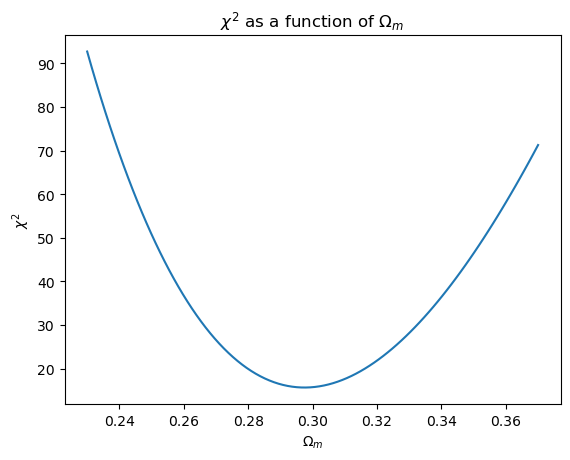

In [2]:
omega_m_values, chi2_values= np.load("chi2_values.npy")

plt.plot(omega_m_values, chi2_values)
plt.title(r"$\chi^2$ as a function of $\Omega_m$")
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$\chi^2$")
plt.show()

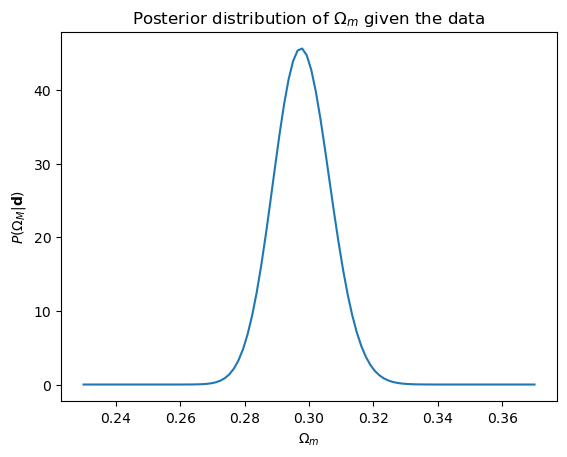

In [3]:
# Converte i valori di chi^2 in una funzione di verosimiglianza (non normalizzata)
posterior = np.exp(-0.5 * chi2_values) 

# Crea un interpolatore continuo della funzione posterior (cubic spline)
interp_posterior = interp1d(omega_m_values, posterior, kind="cubic", fill_value="extrapolate")
# Calcola la normalizzazione integrando la funzione posterior tra omega_m =0.23 e 0.37 (flat prior)
norm_posterior = quad(interp_posterior, a=0.23, b=0.37) 

# Ridefinisce l’interpolatore ma ora con la funzione posterior normalizzata
interp_posterior = interp1d(omega_m_values, posterior/norm_posterior[0], kind="cubic", fill_value="extrapolate")

plt.plot(omega_m_values, posterior/norm_posterior[0])
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$P(\Omega_M|\mathbf{d})$")
plt.title(r"Posterior distribution of $\Omega_m$ given the data")
plt.show()

posterior = posterior/norm_posterior[0] # Salva la posterior normalizzata

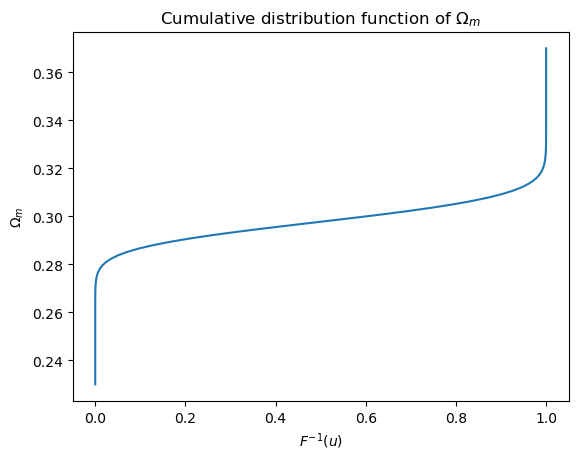

In [4]:
# Calcolo della funzione cumulativa tramite integrazione punto per punto
cumfunc = np.array([quad(interp_posterior, a=0.23, b=om)[0] for om in omega_m_values])

plt.plot(cumfunc, omega_m_values)
plt.xlabel("$F^{-1}(u)$") 
plt.ylabel(r"$\Omega_m$")
plt.title(r"Cumulative distribution function of $\Omega_m$")
plt.show()

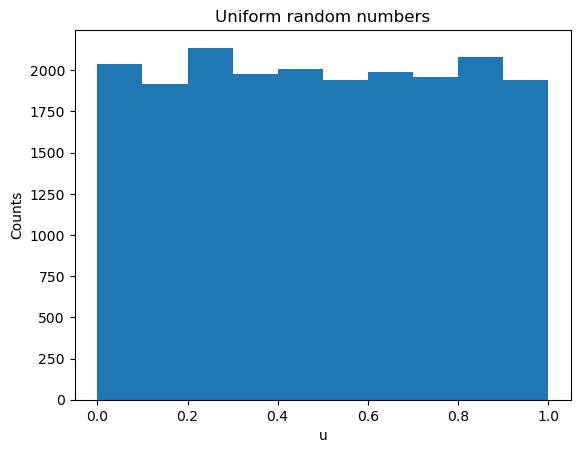

In [5]:
# Interpola la funzione inversa cumulativa
interp_inverse_cumulative = interp1d(cumfunc, omega_m_values, kind="linear")

random_uniform = np.random.uniform(0, 1, 20000)

plt.hist(random_uniform)
plt.xlabel("u")
plt.ylabel("Counts")
plt.title("Uniform random numbers")
plt.show()

In [6]:
# Applica la funzione inversa cumulativa ai numeri uniformi per ottenere una distribuzione campionata di omega_m
omega_m_gen = interp_inverse_cumulative(random_uniform)
np.max(omega_m_gen)

np.float64(0.3382415743775414)

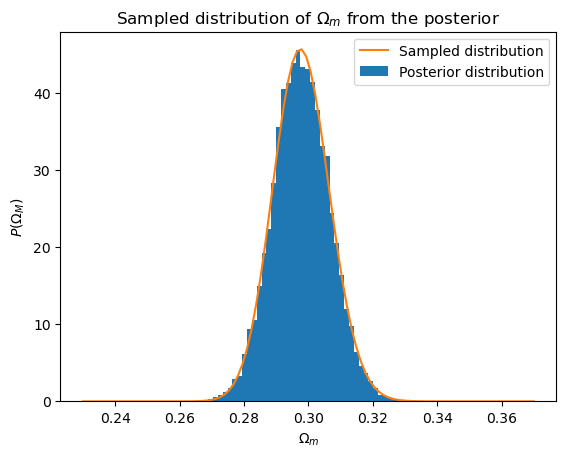

In [7]:
# Istogramma della distribuzione campionata di omega_m
_ = plt.hist(omega_m_gen, bins=50, density=True)  # Mostra distribuzione stimata da campioni
plt.xlabel(r"$\Omega_m$")
plt.ylabel(r"$P(\Omega_M)$")
plt.plot(omega_m_values, posterior)   # Sovrappone la posterior originale per confronto
plt.plot()
plt.title(r"Sampled distribution of $\Omega_m$ from the posterior")
plt.legend(["Sampled distribution", "Posterior distribution"])
plt.show()

In [8]:
# Calcola media e deviazione standard della distribuzione ottenuta
print("Omega_m : {mean:2.4f}+-{std:2.4f}".format(mean=np.mean(omega_m_gen), std=np.std(omega_m_gen)))

Omega_m : 0.2978+-0.0088
